## Config

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
plt.rcParams["figure.figsize"] = (6, 4)
sns.set(style="whitegrid")

# File saving
IMG_DIR = os.path.join("report", "includegraphics")

# create folder if it doesn't exist
os.makedirs(IMG_DIR, exist_ok=True)

def savefig(name):
    """
    Save current matplotlib figure into report/includegraphics folder.
    Automatically adds .png extension.
    """
    path = os.path.join(IMG_DIR, f"{name}.png")
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

## Load dataset and basic inspection

In [ ]:
DATA_PATH = "dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nTarget value counts:")
print(df["target"].value_counts())

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1,0,125.0,212.0,0,1,168.0,0,1.0,2,2.0,3.0,0
1,53.0,1,0,140.0,203.0,1,0,155.0,1,3.1,0,0.0,3.0,0
2,70.0,1,0,145.0,174.0,0,1,125.0,1,2.6,0,0.0,3.0,0
3,61.0,1,0,148.0,203.0,0,1,161.0,0,0.0,2,1.0,3.0,0
4,62.0,0,0,138.0,294.0,1,1,106.0,0,1.9,1,NaN,NaN,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       974 non-null    float64
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  974 non-null    float64
 4   chol      1012 non-null   float64
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1008 non-null   float64
 8   exang     1025 non-null   int64  
 9   oldpeak   1024 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        974 non-null    float64
 12  thal      974 non-null    float64
 13  target    1025 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 112.2 KB
None

Missing values per column:
age         51
sex          0
cp           0
trestbps    51
chol        13
fbs          0
restecg      0
thalach     17
exang        0
oldpeak      1
slope        0
ca          

# Preprocessing
 1- Define feature types<br>
 2- Handle missing and noisy data<br>
 3- Normalizing numerical features<br>

In [ ]:
# 1- Define features types
# Numeric (continuous) features
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Binary / categorical features (Encoded as integer)
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

target_col = "target"


# 2- Handling Missing and niosy Data
def impute_missing_values(df, numeric_cols, categorical_cols):
    """
    Impute missing values:
      - numeric: median
      - categorical: mode
    """
    df = df.copy()
    
    # Numeric
    for col in numeric_cols:
        if df[col].isna().any():
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
    
    # Categorical
    for col in categorical_cols:
        if df[col].isna().any():
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
    
    return df

# 3- Normalizing numerical features
def min_max_scale_train_test(train_df, test_df, numeric_cols):
    """
    Min-Max scale numeric columns based on training set statistics only.
    """
    train_scaled = train_df.copy()
    test_scaled = test_df.copy()
    
    for col in numeric_cols:
        col_min = train_scaled[col].min()
        col_max = train_scaled[col].max()
        
        if col_max > col_min:
            train_scaled[col] = (train_scaled[col] - col_min) / (col_max - col_min)
            test_scaled[col] = (test_scaled[col] - col_min) / (col_max - col_min)
        else:
            # Column is constant
            train_scaled[col] = 0.0
            test_scaled[col] = 0.0
    
    return train_scaled, test_scaled

## Apply missing value imputation

In [13]:
df_imputed = impute_missing_values(df, numeric_cols, categorical_cols)

print("Missing values after imputation:")
print(df_imputed.isna().sum())

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# EDA
1- Histogram<br>
2- Box plot<br>
3- Q-Q plot<br>
4- Correlation matrix<br>
5- Pair plots<br>
6- Count plot

### EDA: Histogram

Saved: report/includegraphics/hist_age.png


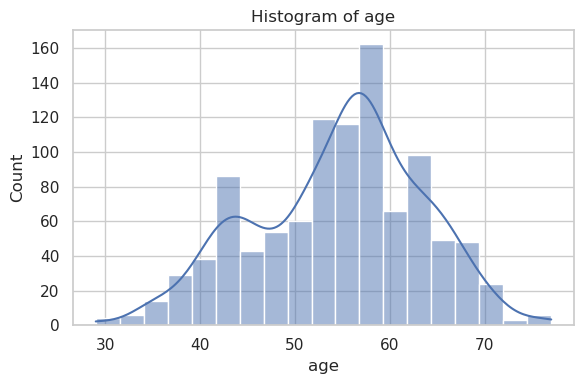

Saved: report/includegraphics/hist_trestbps.png


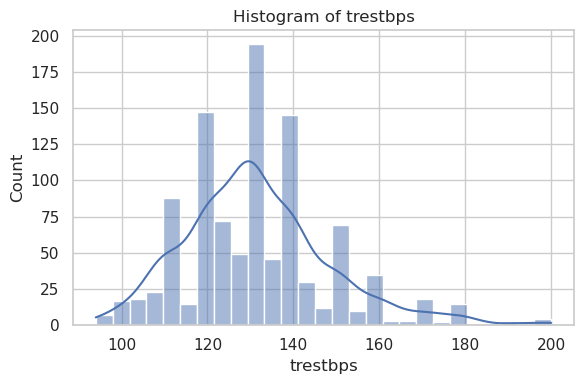

Saved: report/includegraphics/hist_chol.png


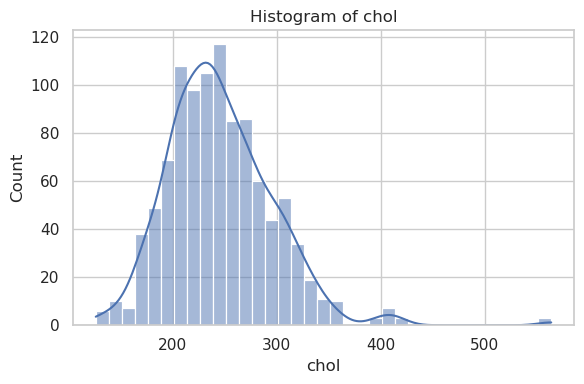

Saved: report/includegraphics/hist_thalach.png


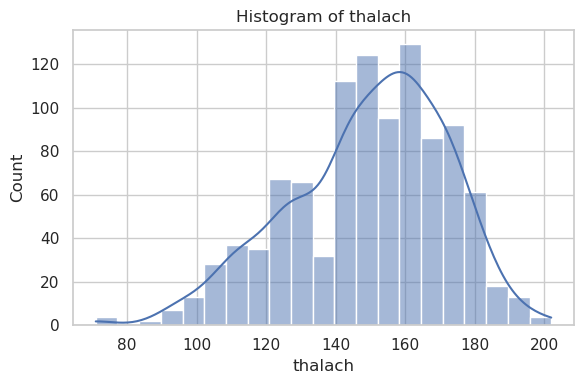

Saved: report/includegraphics/hist_oldpeak.png


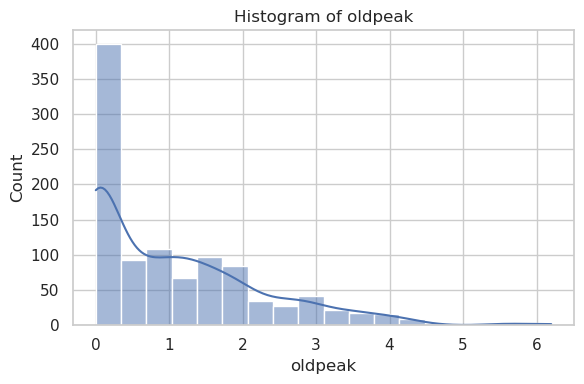

In [39]:
#Histograms for numeric features

for col in numeric_cols:
    plt.figure()
    sns.histplot(df_imputed[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    savefig(f"hist_{col}")
    plt.show()
    

### EDA: Boxplot

Saved: report/includegraphics/boxplot_age.png


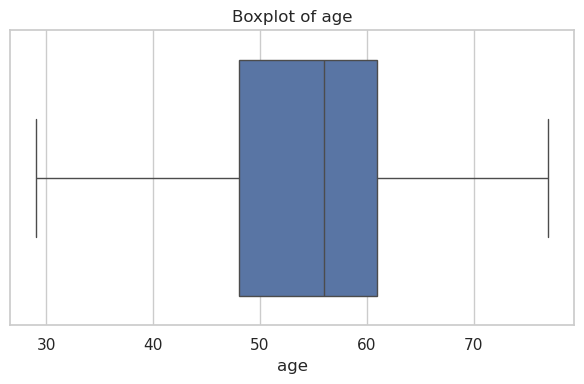

Saved: report/includegraphics/boxplot_trestbps.png


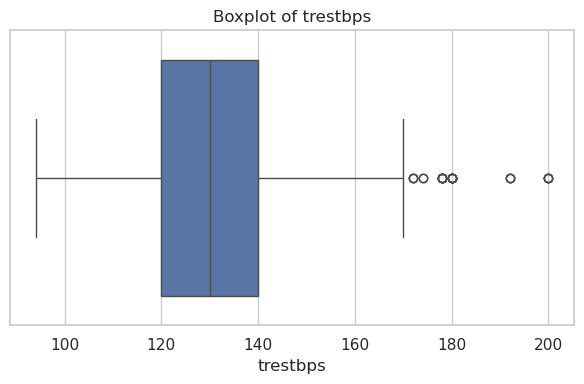

Saved: report/includegraphics/boxplot_chol.png


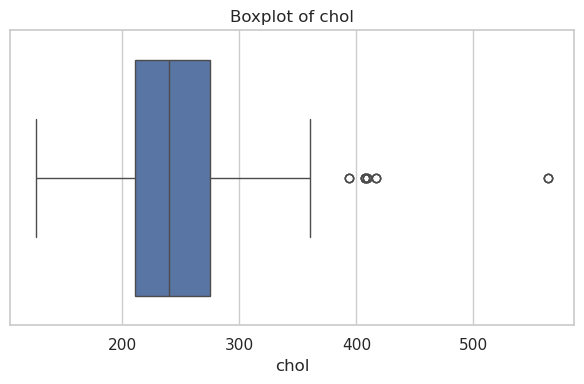

Saved: report/includegraphics/boxplot_thalach.png


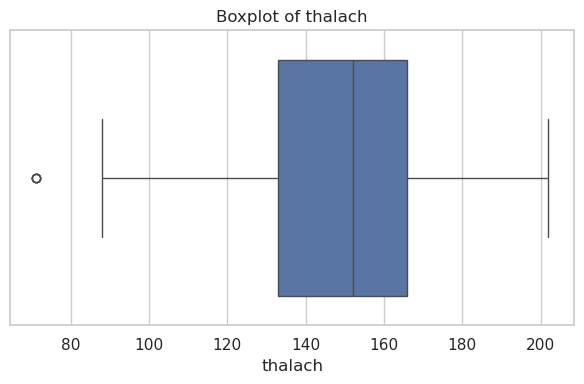

Saved: report/includegraphics/boxplot_oldpeak.png


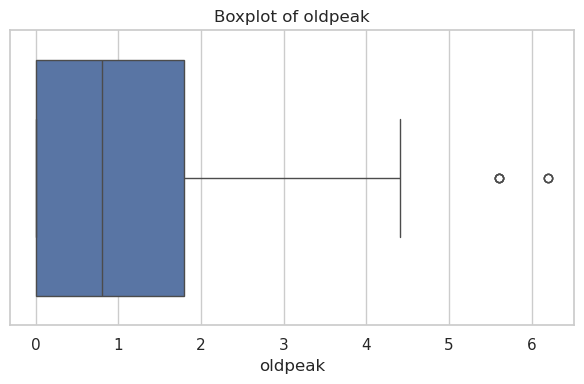

In [41]:
#  Boxplots

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df_imputed[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    savefig(f"boxplot_{col}")
    plt.show()

### EDA: Q–Q Plot

Saved: report/includegraphics/qq_age.png


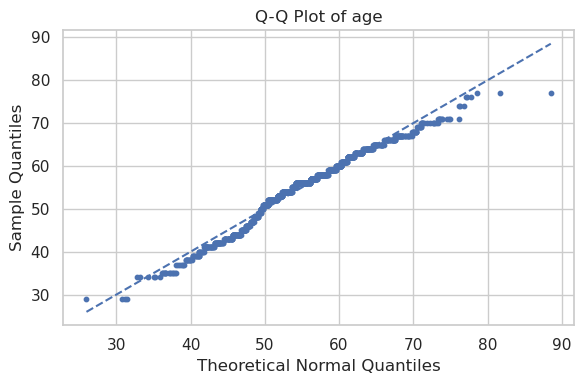

Saved: report/includegraphics/qq_chol.png


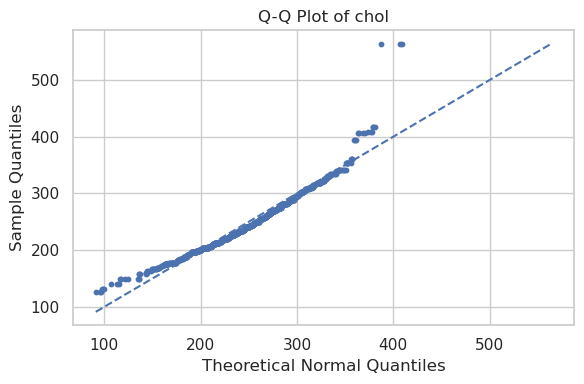

Saved: report/includegraphics/qq_thalach.png


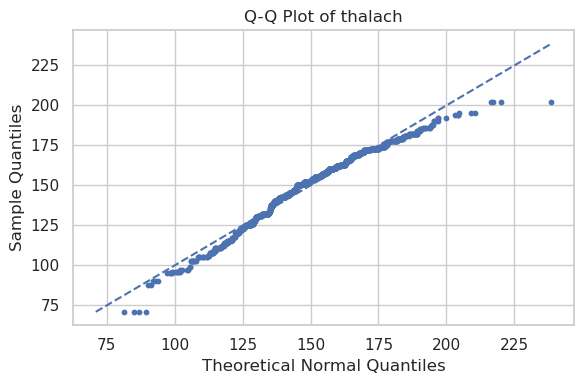

In [42]:
# Simple Q-Q plots

def qq_plot_against_normal(series, ax=None, title=None):
    """
    Simple Q-Q plot: compare sorted data to sorted sample
    from a normal distribution with same mean & std.
    """
    data = series.dropna().values
    data_sorted = np.sort(data)
    n = len(data_sorted)
    
    mu = np.mean(data_sorted)
    sigma = np.std(data_sorted)
    
    # Generate normal sample with same mean and std
    normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)
    normal_sorted = np.sort(normal_sample)
    
    if ax is None:
        fig, ax = plt.subplots()
    
    ax.scatter(normal_sorted, data_sorted, s=10)
    
    # 45-degree reference line
    min_val = min(normal_sorted[0], data_sorted[0])
    max_val = max(normal_sorted[-1], data_sorted[-1])
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    
    ax.set_xlabel("Theoretical Normal Quantiles")
    ax.set_ylabel("Sample Quantiles")
    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title("Q-Q Plot")


# Example Q-Q plots for a few numeric columns
cols_for_qq = ["age", "chol", "thalach"]

for col in cols_for_qq:
    fig, ax = plt.subplots()
    qq_plot_against_normal(df_imputed[col], ax=ax, title=f"Q-Q Plot of {col}")
    plt.tight_layout()
    savefig(f"qq_{col}")
    plt.show()

### EDA: Correlation matrix

Saved: report/includegraphics/corr_matrix.png


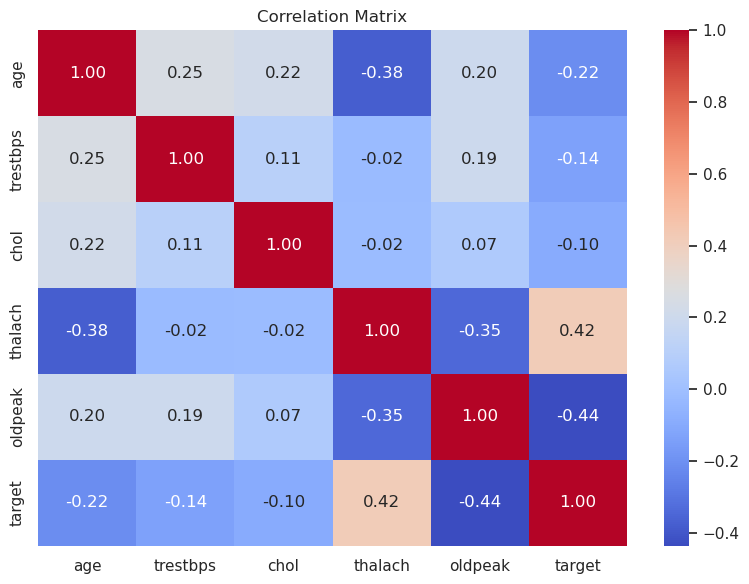

In [43]:
# Correlation matrix (numeric features + target)

corr_cols = numeric_cols + [target_col]
corr_matrix = df_imputed[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
savefig("corr_matrix")
plt.show()

### EDA: Pair plots

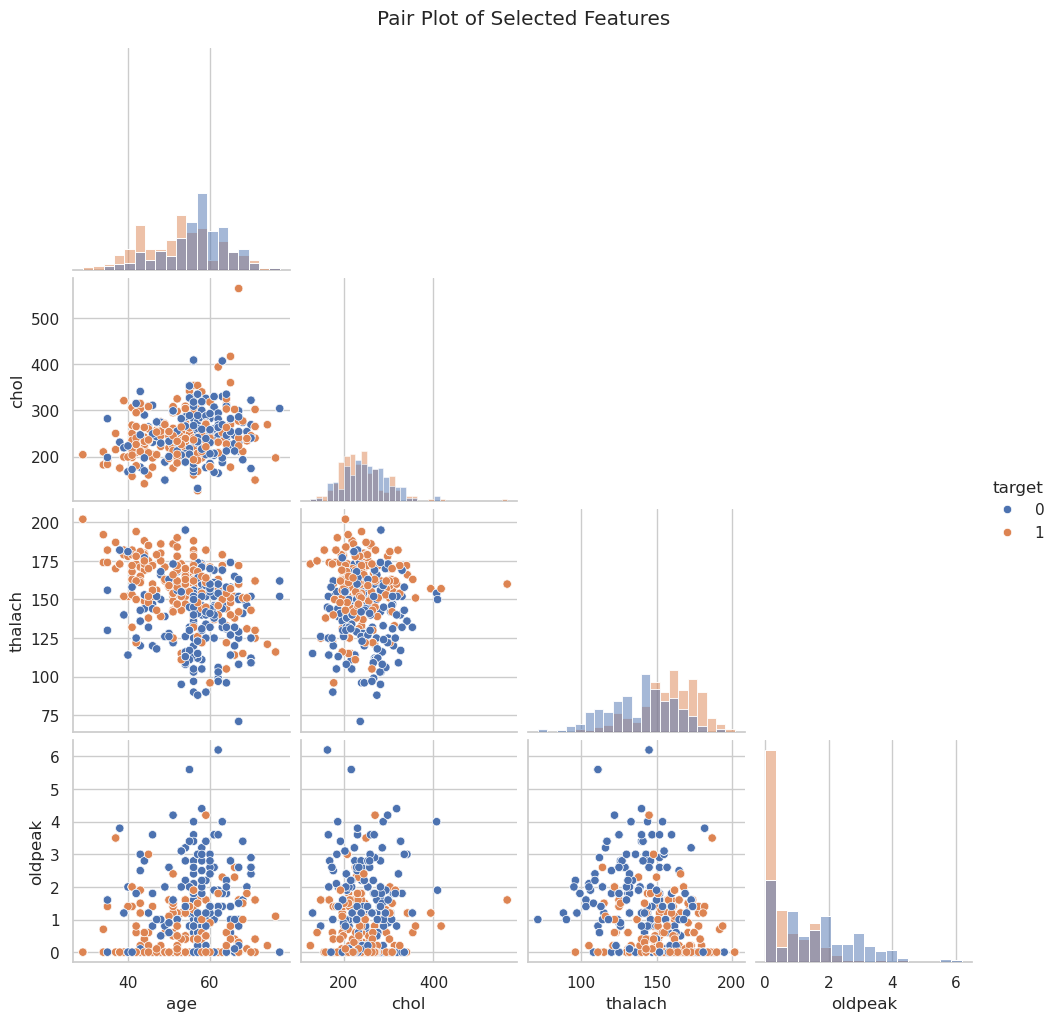

In [44]:
# Pair plots

pairplot_sets = {
    "pairplot_selected": ["age", "chol", "thalach", "oldpeak", target_col],
}

for filename, cols in pairplot_sets.items():
    g = sns.pairplot(
        df_imputed[cols],
        hue=target_col,
        diag_kind="hist",
        corner=True
    )
    g.fig.suptitle("Pair Plot of Selected Features", y=1.02)
    
    g.savefig(f"report/includegraphics/{filename}.png", bbox_inches="tight")
    
    plt.show()
    plt.close(g.fig)

### EDA: Countplot

Saved: report/includegraphics/count_target.png


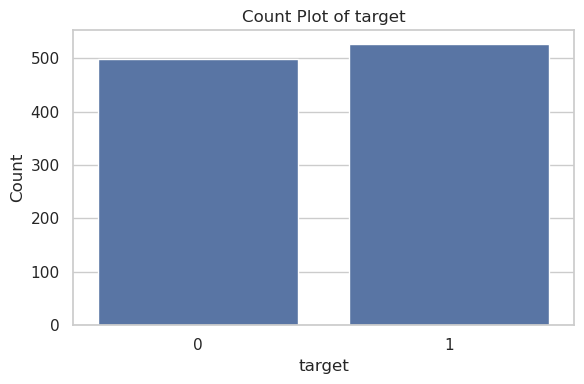

Saved: report/includegraphics/count_sex.png


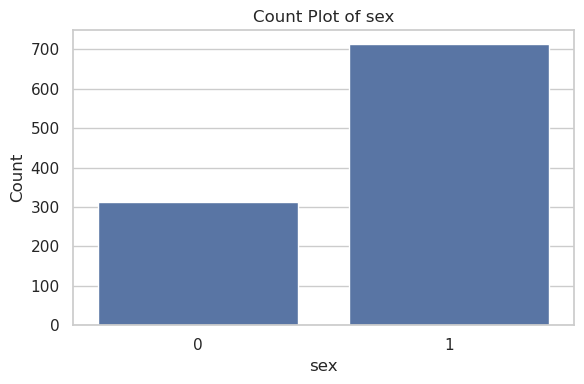

Saved: report/includegraphics/count_cp.png


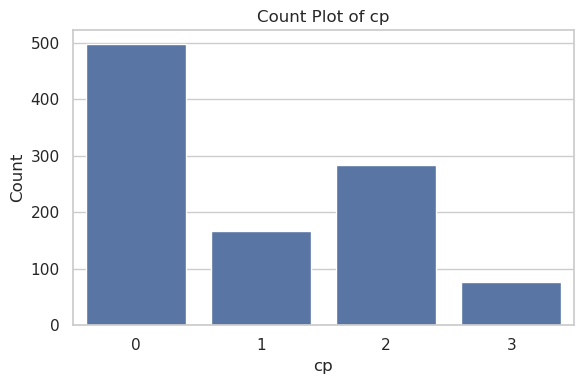

Saved: report/includegraphics/count_exang.png


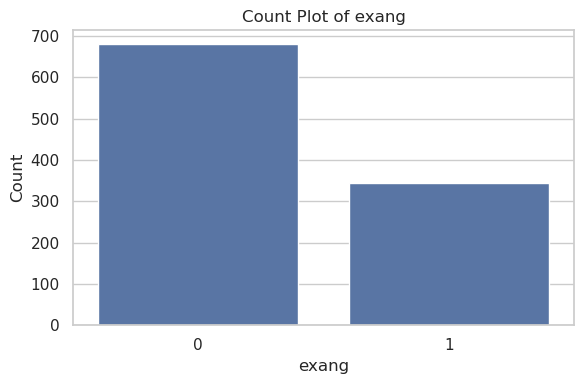

In [45]:
# Count plots (some categorical)

categorical_for_plot = ["target", "sex", "cp", "exang"]

for col in categorical_for_plot:
    plt.figure()
    sns.countplot(x=df_imputed[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    savefig(f"count_{col}")
    plt.show()

# KNN
1- Train-Test Split<br>
2- Min-Max Scaling<br>
3- KNN classifier class<br>
4- Metrics<br>
5- Training and Evaluation<br>
6- confusion matrix<br>
7- Accuracy vs K plot<br>

## Train-test split

In [19]:
# Train-test split

def train_test_split_df(df, test_size=0.2, random_state=42):
    df = df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)  # shuffle
    n = len(df)
    test_count = int(n * test_size)
    test_df = df.iloc[:test_count].copy()
    train_df = df.iloc[test_count:].copy()
    return train_df, test_df


train_df_raw, test_df_raw = train_test_split_df(df_imputed, test_size=0.2, random_state=RANDOM_STATE)

print("Train shape:", train_df_raw.shape)
print("Test shape:", test_df_raw.shape)

Train shape: (820, 14)
Test shape: (205, 14)


## Min-Max scaling

In [20]:
# Scale numeric features with Min-Max (fit on train only)

train_df, test_df = min_max_scale_train_test(train_df_raw, test_df_raw, numeric_cols)

# Separate features and target
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col].values

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (820, 13)
X_test shape: (205, 13)


## Implementation of KNN classifier

In [21]:
# KNN classifiet

class KNNClassifier:
    def __init__(self, k=5, numeric_cols=None, categorical_cols=None, w_num=0.5, w_cat=0.5):
        """
            ** KNN classifier **

        Parameters
        ----------
        * k : int
              Number of neighbors.

        * numeric_cols : list
              Names of numeric feature columns.

        * categorical_cols : list
              Names of categorical feature columns.

        * w_num : float
              Weight for numeric distance.

        * w_cat : float
            Weight for categorical distance.
        """

        self.k = k
        self.numeric_cols = numeric_cols or []
        self.categorical_cols = categorical_cols or []
        self.w_num = w_num
        self.w_cat = w_cat
        
        self.X_num_train = None
        self.X_cat_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Store training data.
        X is a DataFrame, y is a 1D array-like of labels.
        """
        self.X_num_train = X[self.numeric_cols].values.astype(float)
        self.X_cat_train = X[self.categorical_cols].values.astype(float)
        self.y_train = np.array(y)

    def _compute_distances(self, x_num, x_cat):
        """
        Compute combined distance from one sample to all training samples.
        """
        # Numeric: Euclidean distance
        num_diff = self.X_num_train - x_num
        num_dist = np.sqrt(np.sum(num_diff ** 2, axis=1))
        
        # Categorical: Hamming distance (normalized)
        cat_diff = self.X_cat_train != x_cat
        if cat_diff.shape[1] > 0:
            cat_dist = cat_diff.mean(axis=1)
        else:
            cat_dist = np.zeros(len(self.X_num_train))
        
        # Combined distance
        return self.w_num * num_dist + self.w_cat * cat_dist

    def predict_one(self, x_num, x_cat):
        """
        Predict label for a single sample.
        """
        distances = self._compute_distances(x_num, x_cat)
        neighbor_indices = np.argsort(distances)[: self.k]
        neighbor_labels = self.y_train[neighbor_indices]
        
        values, counts = np.unique(neighbor_labels, return_counts=True)
        majority_label = values[np.argmax(counts)]
        return majority_label

    def predict(self, X):
        """
        Predict labels for all samples in X (DataFrame).
        """
        X_num = X[self.numeric_cols].values.astype(float)
        X_cat = X[self.categorical_cols].values.astype(float)
        
        predictions = []
        for i in range(len(X)):
            pred = self.predict_one(X_num[i], X_cat[i])
            predictions.append(pred)
        
        return np.array(predictions)


## Metrics
-accuracy<br>
-precision<br>
-recall<br>
-F1<br>

-confusion matrix

In [22]:
# Metrivs
def binary_classification_metrics(y_true, y_pred, positive_label=1):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    tn = np.sum((y_true != positive_label) & (y_pred != positive_label))
    fp = np.sum((y_true != positive_label) & (y_pred == positive_label))
    fn = np.sum((y_true == positive_label) & (y_pred != positive_label))
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return accuracy, precision, recall, f1, tp, tn, fp, fn


def confusion_matrix_2x2(y_true, y_pred, positive_label=1):
    """
    Return confusion matrix as [[TN, FP], [FN, TP]].
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == positive_label) & (y_pred == positive_label))
    tn = np.sum((y_true != positive_label) & (y_pred != positive_label))
    fp = np.sum((y_true != positive_label) & (y_pred == positive_label))
    fn = np.sum((y_true == positive_label) & (y_pred != positive_label))
    
    return np.array([[tn, fp],
                     [fn, tp]])

## Training

In [28]:
# Train and evaluate KNN for different K values

def evaluate_knn_for_k(k, X_train, y_train, X_test, y_test, numeric_cols, categorical_cols, w_num=0.5, w_cat=0.5):
    knn = KNNClassifier(
        k=k,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        w_num=w_num,
        w_cat=w_cat
    )
    knn.fit(X_train, y_train)

    # Evaluate the test data
    y_pred = knn.predict(X_test)
    acc, prec, rec, f1, tp, tn, fp, fn = binary_classification_metrics(y_test, y_pred)
    cm = confusion_matrix_2x2(y_test, y_pred)
    
    print(f"K = {k}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(cm)
    print("-" * 40)
    
    return acc, prec, rec, f1, cm, y_pred


k_values_to_check = [3, 5, 7]

results = {}
for k in k_values_to_check:
    acc, prec, rec, f1, cm, y_pred = evaluate_knn_for_k(
        k,
        X_train, y_train,
        X_test, y_test,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        w_num=0.5,
        w_cat=0.5
    )
    results[k] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cm": cm,
        "y_pred": y_pred,
    }

K = 3
Accuracy : 0.9317
Precision: 0.9159
Recall   : 0.9515
F1-score : 0.9333
Confusion matrix [[TN, FP], [FN, TP]]:
[[93  9]
 [ 5 98]]
----------------------------------------
K = 5
Accuracy : 0.8195
Precision: 0.7946
Recall   : 0.8641
F1-score : 0.8279
Confusion matrix [[TN, FP], [FN, TP]]:
[[79 23]
 [14 89]]
----------------------------------------
K = 7
Accuracy : 0.8341
Precision: 0.8053
Recall   : 0.8835
F1-score : 0.8426
Confusion matrix [[TN, FP], [FN, TP]]:
[[80 22]
 [12 91]]
----------------------------------------


## confusion matrix

Saved: report/includegraphics/Confusion Matrix.png


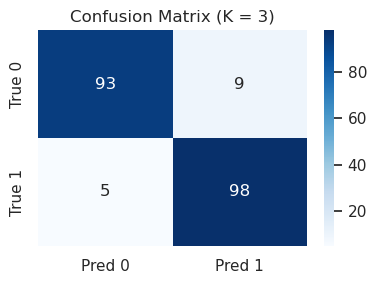

Best K based on accuracy: 3
Metrics: {'accuracy': 0.9317073170731708, 'precision': 0.9158878504672897, 'recall': 0.9514563106796117, 'f1': 0.9333333333333335, 'cm': array([[93,  9],
       [ 5, 98]]), 'y_pred': array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0])}


In [ ]:
# Confusion matrix for the best K (highest accuracy)

best_k = max(results, key=lambda k: results[k]["accuracy"])
best_cm = results[best_k]["cm"]

plt.figure(figsize=(4, 3))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)
plt.title(f"Confusion Matrix (K = {best_k})")
plt.tight_layout()
savefig("confusion_matrix")
plt.show()

print(f"Best K based on accuracy: {best_k}")
print("Metrics:", results[best_k])

## Accuracy vs K plot

K = 1
Accuracy : 0.9854
Precision: 1.0000
Recall   : 0.9709
F1-score : 0.9852
Confusion matrix [[TN, FP], [FN, TP]]:
[[102   0]
 [  3 100]]
----------------------------------------
K = 3
Accuracy : 0.9317
Precision: 0.9159
Recall   : 0.9515
F1-score : 0.9333
Confusion matrix [[TN, FP], [FN, TP]]:
[[93  9]
 [ 5 98]]
----------------------------------------
K = 5
Accuracy : 0.8195
Precision: 0.7946
Recall   : 0.8641
F1-score : 0.8279
Confusion matrix [[TN, FP], [FN, TP]]:
[[79 23]
 [14 89]]
----------------------------------------
K = 7
Accuracy : 0.8341
Precision: 0.8053
Recall   : 0.8835
F1-score : 0.8426
Confusion matrix [[TN, FP], [FN, TP]]:
[[80 22]
 [12 91]]
----------------------------------------
K = 9
Accuracy : 0.8537
Precision: 0.8349
Recall   : 0.8835
F1-score : 0.8585
Confusion matrix [[TN, FP], [FN, TP]]:
[[84 18]
 [12 91]]
----------------------------------------
K = 11
Accuracy : 0.8488
Precision: 0.8103
Recall   : 0.9126
F1-score : 0.8584
Confusion matrix [[TN, FP], [FN,

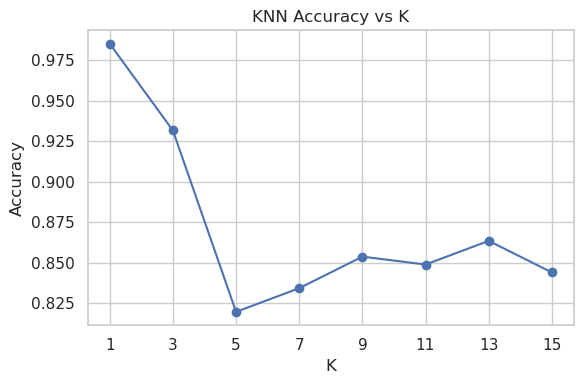

In [47]:
# Accuracy vs K plot

k_range = list(range(1, 16, 2))  # odd values: 1,3,5,...,15
accuracies = []

for k in k_range:
    acc, prec, rec, f1, cm, y_pred = evaluate_knn_for_k(
        k,
        X_train, y_train,
        X_test, y_test,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        w_num=0.5,
        w_cat=0.5
    )
    accuracies.append(acc)

plt.figure()
plt.plot(k_range, accuracies, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
savefig("KNN Accuracy vs K")
plt.show()
